In [1]:
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

from pmdarima import auto_arima
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

## 0. Data preparation

The matrices use subject codes as row labels, but `.iloc` selects by row position.  
For example, subject code 14 is currently at row position 9.

In [3]:
# Use annual data from 1900 through 2024.
years = np.arange(1900, 2025)

valid_pure = nodes[
    nodes["subject_code"].notna()
    & (nodes["subject_code"] < 61)
    & nodes["year"].between(1900, 2024)
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = (
    pd.crosstab(valid_pure["subject_code"], valid_pure["year"])
    .reindex(index=codes_pure, columns=years, fill_value=0)
)

year_totals = counts.sum(axis=0).replace(0, np.nan)
share = counts.div(year_totals, axis=1) * 100

print("counts shape:", counts.shape)
print("share shape:", share.shape)
print("Years with undefined shares:", share.columns[share.isna().any()].tolist())

counts shape: (44, 125)
share shape: (44, 125)
Years with undefined shares: []


In [4]:
# Select subject code 14 by first finding its row position.
subject_code = 14

matching_positions = np.flatnonzero(
    counts.index.to_numpy() == subject_code
)

if len(matching_positions) == 0:
    raise KeyError(f"Subject code {subject_code} is not present in counts.")

subject_row_position = int(matching_positions[0])

counts_subject14 = counts.iloc[subject_row_position].astype(float)
share_subject14 = share.iloc[subject_row_position].astype(float)
year_values = counts.columns.to_numpy(dtype=int)

print("Subject code:", subject_code)
print("Row position:", subject_row_position)
print("Row label at that position:", counts.index[subject_row_position])

Subject code: 14
Row position: 9
Row label at that position: 14.0


## 1. Forecasting models

In [5]:
def forecast_models(train, train_years, forecast_years):
    """Fit all candidate models using one training fold."""

    train = np.asarray(train, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    forecast_years = np.asarray(forecast_years, dtype=float)
    horizon = len(forecast_years)

    forecasts = {}

    # 1. Simple exponential smoothing with fixed alpha.
    ses_model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        smoothing_level=0.5,
        optimized=False
    )
    forecasts["Simple exponential smoothing"] = np.asarray(
        ses_model.forecast(horizon),
        dtype=float
    )

    # 2. Ordinary Holt model, with parameters estimated inside the fold.
    holt_optimized = Holt(
        train,
        damped_trend=False,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt optimized"] = np.asarray(
        holt_optimized.forecast(horizon),
        dtype=float
    )

    # 3. Damped Holt model, with parameters estimated inside the fold.
    holt_damped = Holt(
        train,
        damped_trend=True,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt damped"] = np.asarray(
        holt_damped.forecast(horizon),
        dtype=float
    )

    # 4. Linear trend fitted only on the years in this training fold.
    linear_model = LinearRegression()
    linear_model.fit(train_years.reshape(-1, 1), train)
    forecasts["Linear trend"] = linear_model.predict(
        forecast_years.reshape(-1, 1)
    )

    # 5. Fixed ARIMA(0, 0, 2).
    arima_002_model = pm.ARIMA(
        order=(0, 0, 2),
        with_intercept=False,
        suppress_warnings=True
    ).fit(train)
    forecasts["ARIMA(0,0,2)"] = np.asarray(
        arima_002_model.predict(n_periods=horizon),
        dtype=float
    )

    # 6. Auto-ARIMA.
    auto_model = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )
    forecasts["Auto ARIMA"] = np.asarray(
        auto_model.predict(n_periods=horizon),
        dtype=float
    )

    return forecasts

## 2. Rolling-window cross-validation

In [6]:
def rolling_window_cv(
    y,
    year_values,
    window_size=40,
    horizon=5,
    step=5
):
    """Run fixed-length rolling-window time-series cross-validation.

    Returns
    -------
    metrics : pandas.DataFrame
        One row per fold and model.
    forecast_details : pandas.DataFrame
        One row per forecasted year and model.
    """

    y = np.asarray(y, dtype=float)
    year_values = np.asarray(year_values)

    if len(y) != len(year_values):
        raise ValueError("y and year_values must have the same length.")

    if window_size < 2:
        raise ValueError("window_size must be at least 2.")

    if horizon < 1 or step < 1:
        raise ValueError("horizon and step must be positive.")

    if window_size + horizon > len(y):
        raise ValueError(
            "window_size + horizon cannot exceed the series length."
        )

    if np.isnan(y).any():
        missing_years = year_values[np.isnan(y)]
        raise ValueError(
            f"The series contains missing values in years "
            f"{missing_years.tolist()}."
        )

    metric_records = []
    forecast_records = []
    fold_number = 0

    for test_start in range(
        window_size,
        len(y) - horizon + 1,
        step
    ):
        fold_number += 1

        train_start = test_start - window_size
        test_end = test_start + horizon

        train = y[train_start:test_start]
        test = y[test_start:test_end]

        train_years = year_values[train_start:test_start]
        test_years = year_values[test_start:test_end]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            forecasts = forecast_models(
                train=train,
                train_years=train_years,
                forecast_years=test_years
            )

        mase_scale = np.mean(np.abs(np.diff(train)))

        for model_name, prediction in forecasts.items():
            prediction = np.asarray(prediction, dtype=float)

            if len(prediction) != len(test):
                raise ValueError(
                    f"{model_name} returned {len(prediction)} predictions "
                    f"for a test set of length {len(test)}."
                )

            fold_mse = mean_squared_error(test, prediction)
            fold_mae = mean_absolute_error(test, prediction)

            metric_records.append({
                "fold": fold_number,
                "model": model_name,
                "train_start": int(train_years[0]),
                "train_end": int(train_years[-1]),
                "test_start": int(test_years[0]),
                "test_end": int(test_years[-1]),
                "MSE": fold_mse,
                "RMSE": np.sqrt(fold_mse),
                "MAE": fold_mae,
                "MASE": (
                    fold_mae / mase_scale
                    if mase_scale > 0
                    else np.nan
                )
            })

            for year, actual, predicted in zip(
                test_years,
                test,
                prediction
            ):
                forecast_records.append({
                    "fold": fold_number,
                    "model": model_name,
                    "year": int(year),
                    "actual": float(actual),
                    "predicted": float(predicted),
                    "error": float(actual - predicted)
                })

    metrics = pd.DataFrame(metric_records)
    forecast_details = pd.DataFrame(forecast_records)

    return metrics, forecast_details

In [7]:
def summarize_cv_results(cv_metrics):
    """Average the error measures across validation folds."""

    if cv_metrics.empty:
        return pd.DataFrame()

    return (
        cv_metrics
        .groupby("model")
        .agg(
            mean_MSE=("MSE", "mean"),
            std_MSE=("MSE", "std"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .sort_values("mean_MSE")
    )

## 3. Subject 14: five-year rolling forecasts

With `window_size=40`, `horizon=5`, and `step=5`, every fold trains on exactly 40 years and predicts the next 5 years.

In [8]:
counts_rolling_metrics, counts_rolling_forecasts = rolling_window_cv(
    y=counts_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

counts_rolling_summary = summarize_cv_results(
    counts_rolling_metrics
)
counts_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Auto ARIMA,239.585849,441.318261,11.293520,10.086186,2.036386,17
Holt damped,247.561592,433.798221,11.346155,10.061816,1.893915,17
Holt optimized,256.364924,455.572721,11.513539,10.301705,1.950997,17
Simple exponential smoothing,281.584451,639.510052,11.803194,10.378563,2.082015,17
Linear trend,347.471699,628.023144,13.850465,12.468670,2.455464,17
"ARIMA(0,0,2)",4789.261874,7602.019859,47.989807,45.389265,7.535565,17


In [9]:
share_rolling_metrics, share_rolling_forecasts = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

share_rolling_summary = summarize_cv_results(
    share_rolling_metrics
)
share_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,2.916242,5.233893,1.315016,1.142408,0.678333,17
Holt optimized,2.996028,5.399155,1.364355,1.182485,0.675882,17
Linear trend,3.098500,3.435763,1.496098,1.342957,0.770644,17
Holt damped,3.785425,8.275471,1.427135,1.257610,0.682527,17
Auto ARIMA,7.478432,16.357815,1.889330,1.722592,0.739154,17
"ARIMA(0,0,2)",17.888758,12.946797,4.002245,3.721351,3.744273,17


### 3.1 Error by rolling fold

In [10]:
share_rolling_metrics.pivot(
    index="fold",
    columns="model",
    values="MSE"
)

model,"ARIMA(0,0,2)",Auto ARIMA,Holt damped,Holt optimized,Linear trend,Simple exponential smoothing
fold,,,,,,
1,19.603644,19.180001,12.456900,22.192681,5.877143,14.267256
2,7.432829,66.784379,33.825167,8.627149,8.627145,18.629601
3,14.550476,16.348905,4.220818,4.474634,2.296975,3.449676
4,5.197040,10.155347,1.312443,3.158223,1.232630,1.262150
5,10.166125,3.740789,1.699597,2.468582,1.682910,2.382741
6,5.446305,0.464208,0.378187,0.389964,7.649599,0.401188
7,5.600198,3.125297,1.143900,0.539758,10.868966,0.685012
8,7.707500,0.666683,1.087017,0.582103,6.493851,0.565326
9,13.543084,2.521385,3.005147,3.135299,3.135298,1.790327


### 3.2 Plot rolling forecasts

In [11]:
def plot_cv_forecasts(
    original_series,
    year_values,
    cv_forecasts,
    model_name,
    title
):
    plt.figure(figsize=(16, 7))

    plt.plot(
        year_values,
        original_series,
        label="Actual series",
        linewidth=2
    )

    selected = cv_forecasts[
        cv_forecasts["model"] == model_name
    ]

    for fold in selected["fold"].unique():
        fold_data = selected[selected["fold"] == fold]

        plt.plot(
            fold_data["year"],
            fold_data["predicted"],
            marker="o",
            linestyle="--",
            alpha=0.8
        )

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()

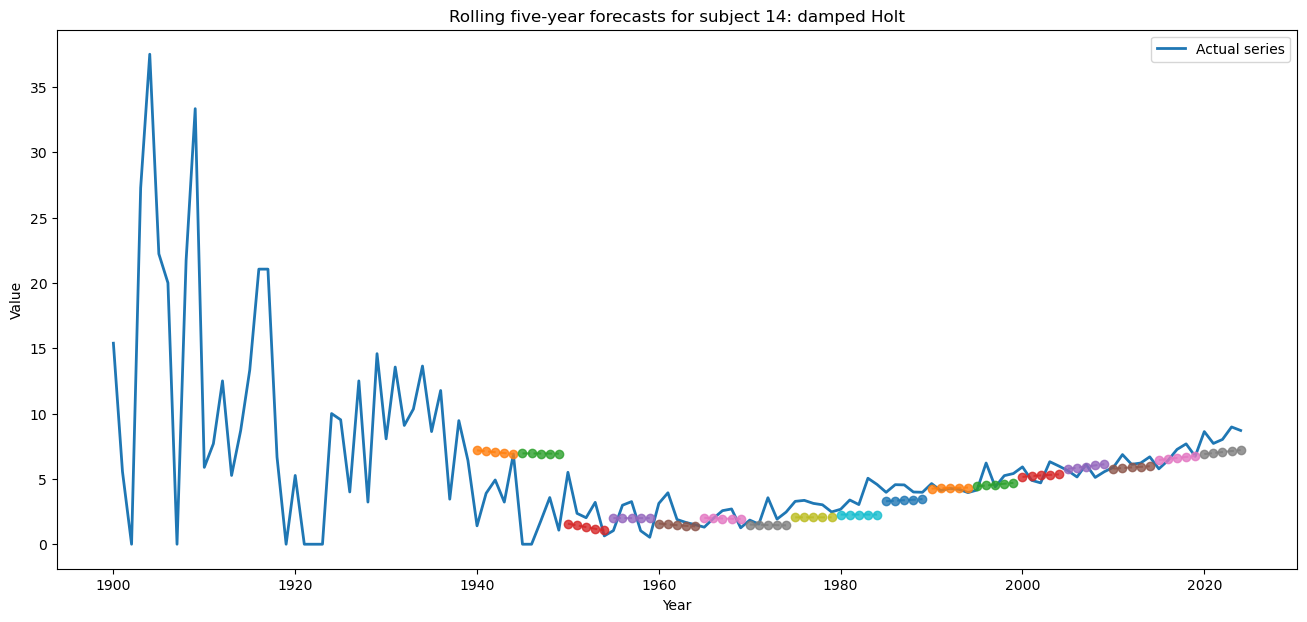

In [12]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling five-year forecasts for subject 14: "
        "damped Holt"
    )
)

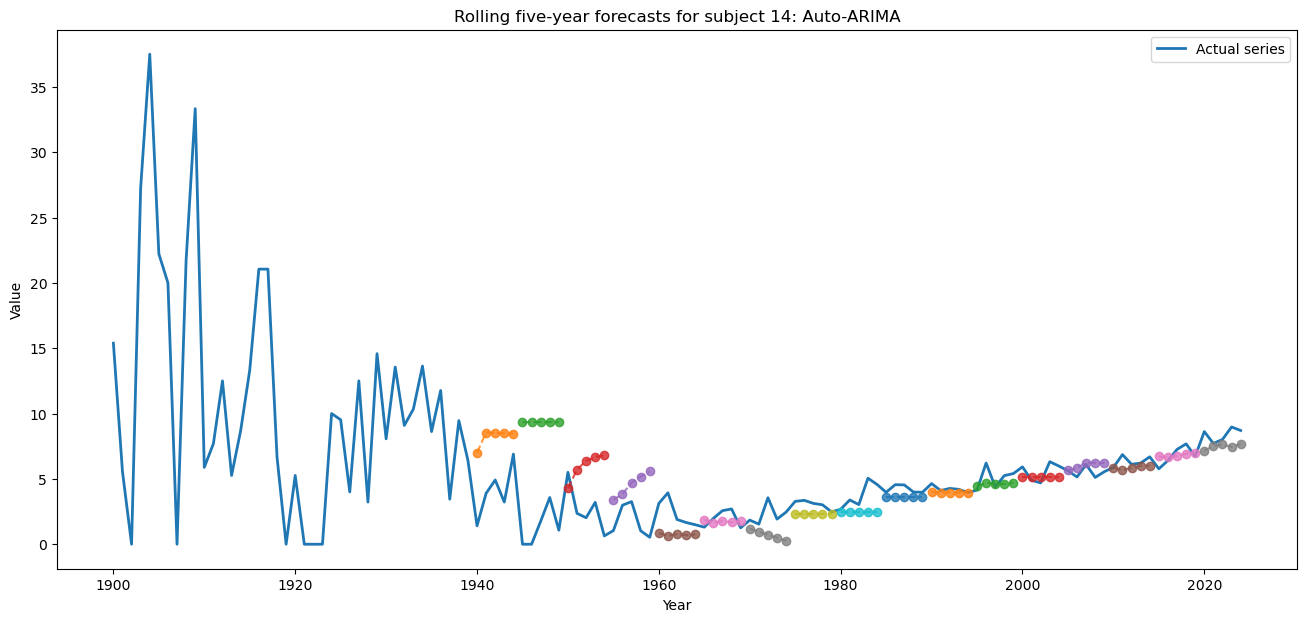

In [13]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Auto ARIMA",
    title=(
        "Rolling five-year forecasts for subject 14: "
        "Auto-ARIMA"
    )
)

## 4. One-year versus five-year rolling forecasts

In [14]:
share_cv_1year, share_forecasts_1year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=1,
    step=1
)

share_summary_1year = summarize_cv_results(
    share_cv_1year
)
share_summary_1year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,1.907701,5.224596,0.922831,0.922831,0.550969,85
Holt optimized,2.200041,6.164865,1.003651,1.003651,0.580982,85
Linear trend,2.594067,4.085025,1.247020,1.247020,0.721784,85
Holt damped,3.259638,8.261555,1.177843,1.177843,0.626829,85
Auto ARIMA,4.033792,10.966136,1.290405,1.290405,0.650693,85
"ARIMA(0,0,2)",6.902014,8.431100,2.227386,2.227386,1.822176,85


In [15]:
share_cv_5year, share_forecasts_5year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

share_summary_5year = summarize_cv_results(
    share_cv_5year
)
share_summary_5year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Simple exponential smoothing,2.916242,5.233893,1.315016,1.142408,0.678333,17
Holt optimized,2.996028,5.399155,1.364355,1.182485,0.675882,17
Linear trend,3.098500,3.435763,1.496098,1.342957,0.770644,17
Holt damped,3.785425,8.275471,1.427135,1.257610,0.682527,17
Auto ARIMA,7.478432,16.357815,1.889330,1.722592,0.739154,17
"ARIMA(0,0,2)",17.888758,12.946797,4.002245,3.721351,3.744273,17


## 5. Rolling cross-validation for all subjects

In [16]:
def cross_validate_all_subjects(
    matrix,
    window_size=40,
    horizon=5,
    step=5
):
    """Run rolling-window CV on every row of a subject matrix."""

    all_results = []
    failed_subjects = []

    matrix_years = matrix.columns.to_numpy(dtype=int)

    for row_position in range(matrix.shape[0]):
        subject_code = matrix.index[row_position]
        y = matrix.iloc[row_position].astype(float)

        print(
            f"Processing row {row_position}, "
            f"subject code {subject_code}"
        )

        try:
            metrics, _ = rolling_window_cv(
                y=y.to_numpy(),
                year_values=matrix_years,
                window_size=window_size,
                horizon=horizon,
                step=step
            )

            metrics["row_position"] = row_position
            metrics["subject_code"] = subject_code
            all_results.append(metrics)

        except Exception as error:
            failed_subjects.append({
                "row_position": row_position,
                "subject_code": subject_code,
                "error": str(error)
            })
            print(
                f"Subject code {subject_code} failed: {error}"
            )

    if all_results:
        results = pd.concat(
            all_results,
            ignore_index=True
        )
    else:
        results = pd.DataFrame()

    failures = pd.DataFrame(failed_subjects)

    return results, failures

In [17]:
def summarize_models_by_subject(all_cv_results):
    """Summarize each model separately for every subject."""

    if all_cv_results.empty:
        return pd.DataFrame()

    return (
        all_cv_results
        .groupby(
            ["row_position", "subject_code", "model"]
        )
        .agg(
            mean_MSE=("MSE", "mean"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .reset_index()
    )


def select_best_model_by_subject(subject_model_summary):
    """Choose the lowest-mean-MSE model for each subject."""

    if subject_model_summary.empty:
        return pd.DataFrame()

    return (
        subject_model_summary
        .sort_values(
            ["subject_code", "mean_MSE"]
        )
        .groupby("subject_code", as_index=False)
        .first()
    )

### 5.1 Percentage series for all subjects

In [18]:
all_share_cv_results, share_cv_failures = cross_validate_all_subjects(
    matrix=share,
    window_size=40,
    horizon=5,
    step=5
)

print("Failed share series:", len(share_cv_failures))
share_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [19]:
share_subject_model_summary = summarize_models_by_subject(
    all_share_cv_results
)

share_best_model_by_subject = select_best_model_by_subject(
    share_subject_model_summary
)

share_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Holt damped,0.266819,0.439830,0.364129,0.800201,17
1,1.0,1,Holt optimized,1.291757,0.779806,0.650086,0.453666,17
2,3.0,2,Holt damped,3.657050,1.385608,1.104425,0.550393,17
3,5.0,3,Simple exponential smoothing,0.824660,0.844144,0.722622,0.837407,17
4,6.0,4,Holt damped,0.512667,0.531662,0.462668,0.570258,17
5,8.0,5,Auto ARIMA,0.185904,0.348775,0.297510,0.620354,17
6,11.0,6,Simple exponential smoothing,3.038632,1.342872,1.177750,0.509932,17
7,12.0,7,Simple exponential smoothing,0.040577,0.167072,0.129959,0.533672,17
8,13.0,8,Holt damped,0.460099,0.536235,0.449461,0.878026,17
9,14.0,9,Simple exponential smoothing,2.916242,1.315016,1.142408,0.678333,17


### 5.2 Count series for all subjects

In [20]:
all_counts_cv_results, counts_cv_failures = cross_validate_all_subjects(
    matrix=counts,
    window_size=40,
    horizon=5,
    step=5
)

print("Failed count series:", len(counts_cv_failures))
counts_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [21]:
counts_subject_model_summary = summarize_models_by_subject(
    all_counts_cv_results
)

counts_best_model_by_subject = select_best_model_by_subject(
    counts_subject_model_summary
)

counts_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Simple exponential smoothing,33.814632,3.967528,3.375263,1.925892,17
1,1.0,1,Holt optimized,6.718660,2.338438,2.009099,0.975858,17
2,3.0,2,Simple exponential smoothing,142.876892,10.164075,8.771995,2.341787,17
3,5.0,3,Auto ARIMA,430.104612,13.863926,12.539727,2.962358,17
4,6.0,4,Simple exponential smoothing,11.780476,3.130757,2.677610,2.097508,17
5,8.0,5,Simple exponential smoothing,7.743259,2.366137,2.055290,1.751289,17
6,11.0,6,Auto ARIMA,443.936643,15.241693,13.988330,2.378862,17
7,12.0,7,Simple exponential smoothing,3.185120,1.507900,1.286320,1.625884,17
8,13.0,8,Simple exponential smoothing,42.756207,5.089813,4.407900,2.639455,17
9,14.0,9,Auto ARIMA,239.585849,11.293520,10.086186,2.036386,17


## 6. Selection for the best model

In [22]:
def model_vote_summary(
    subject_model_summary,
    metric="mean_MSE",
    tie_tolerance=1e-12
):
    """
    Give each subject one total vote to the model(s) with the lowest error.

    If multiple models tie for one subject, that subject's vote is divided
    equally among the tied models.

    Parameters
    ----------
    subject_model_summary : pandas.DataFrame
        Output from summarize_models_by_subject().

    metric : str
        Metric used to select the best model for each subject.
        Examples: "mean_MSE", "mean_RMSE", "mean_MAE", "mean_MASE".

    tie_tolerance : float
        Numerical tolerance used when detecting ties.

    Returns
    -------
    subject_votes : pandas.DataFrame
        Winning model(s) and assigned vote for every subject.

    vote_summary : pandas.DataFrame
        Total votes and vote percentages for every model.
    """

    required_columns = {
        "row_position",
        "subject_code",
        "model",
        metric
    }

    missing_columns = required_columns.difference(
        subject_model_summary.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    results = (
        subject_model_summary
        .dropna(subset=[metric])
        .copy()
    )

    if results.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Best score for each subject
    results["best_score_for_subject"] = (
        results
        .groupby("subject_code")[metric]
        .transform("min")
    )

    # Keep every model tied for the best score
    subject_votes = results[
        np.isclose(
            results[metric],
            results["best_score_for_subject"],
            rtol=tie_tolerance,
            atol=tie_tolerance
        )
    ].copy()

    # Divide one subject's vote equally if there is a tie
    subject_votes["number_of_tied_models"] = (
        subject_votes
        .groupby("subject_code")["model"]
        .transform("count")
    )

    subject_votes["vote"] = (
        1 / subject_votes["number_of_tied_models"]
    )

    subject_votes = subject_votes[
        [
            "row_position",
            "subject_code",
            "model",
            metric,
            "number_of_tied_models",
            "vote"
        ]
    ].sort_values(
        ["subject_code", "model"]
    )

    number_of_subjects = (
        results["subject_code"].nunique()
    )

    # Include models that received zero votes
    all_models = pd.DataFrame({
        "model": sorted(results["model"].unique())
    })

    vote_summary = (
        subject_votes
        .groupby("model", as_index=False)
        .agg(
            total_votes=("vote", "sum"),
            subjects_with_win=("subject_code", "nunique")
        )
    )

    vote_summary = (
        all_models
        .merge(
            vote_summary,
            on="model",
            how="left"
        )
        .fillna(
            {
                "total_votes": 0,
                "subjects_with_win": 0
            }
        )
    )

    vote_summary["vote_percentage"] = (
        100
        * vote_summary["total_votes"]
        / number_of_subjects
    )

    vote_summary["rank"] = (
        vote_summary["total_votes"]
        .rank(
            method="dense",
            ascending=False
        )
        .astype(int)
    )

    vote_summary["number_of_subjects"] = number_of_subjects

    vote_summary = vote_summary[
        [
            "rank",
            "model",
            "total_votes",
            "vote_percentage",
            "subjects_with_win",
            "number_of_subjects"
        ]
    ].sort_values(
        ["rank", "model"]
    ).reset_index(drop=True)

    return subject_votes, vote_summary


# ============================================================
# Count-series voting
# ============================================================

counts_subject_votes, counts_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=counts_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for count series:")
display(counts_model_vote_summary)

counts_selected_model = (
    counts_model_vote_summary.iloc[0]["model"]
    if not counts_model_vote_summary.empty
    else None
)

print("Selected count-series model:", counts_selected_model)


# ============================================================
# Share-series voting
# ============================================================

share_subject_votes, share_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=share_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for share series:")
display(share_model_vote_summary)

share_selected_model = (
    share_model_vote_summary.iloc[0]["model"]
    if not share_model_vote_summary.empty
    else None
)

print("Selected share-series model:", share_selected_model)


# ============================================================
# Optional: inspect which model won for every subject
# ============================================================

print("Count-series winners by subject:")
display(counts_subject_votes)

print("Share-series winners by subject:")
display(share_subject_votes)

Model voting results for count series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Simple exponential smoothing,28.0,63.636364,28.0,44
1,2,Auto ARIMA,9.0,20.454545,9.0,44
2,3,Holt damped,3.0,6.818182,3.0,44
3,4,Holt optimized,2.0,4.545455,2.0,44
4,4,Linear trend,2.0,4.545455,2.0,44
5,5,"ARIMA(0,0,2)",0.0,0.000000,0.0,44


Selected count-series model: Simple exponential smoothing
Model voting results for share series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Simple exponential smoothing,17.0,38.636364,17.0,44
1,2,Holt damped,12.0,27.272727,12.0,44
2,3,Auto ARIMA,5.0,11.363636,5.0,44
3,3,Holt optimized,5.0,11.363636,5.0,44
4,3,Linear trend,5.0,11.363636,5.0,44
5,4,"ARIMA(0,0,2)",0.0,0.000000,0.0,44


Selected share-series model: Simple exponential smoothing
Count-series winners by subject:


,row_position,subject_code,model,mean_MSE,number_of_tied_models,vote
5,0,0.0,Simple exponential smoothing,33.814632,1,1.0
9,1,1.0,Holt optimized,6.718660,1,1.0
17,2,3.0,Simple exponential smoothing,142.876892,1,1.0
19,3,5.0,Auto ARIMA,430.104612,1,1.0
29,4,6.0,Simple exponential smoothing,11.780476,1,1.0
35,5,8.0,Simple exponential smoothing,7.743259,1,1.0
37,6,11.0,Auto ARIMA,443.936643,1,1.0
47,7,12.0,Simple exponential smoothing,3.185120,1,1.0
53,8,13.0,Simple exponential smoothing,42.756207,1,1.0
55,9,14.0,Auto ARIMA,239.585849,1,1.0


Share-series winners by subject:


,row_position,subject_code,model,mean_MSE,number_of_tied_models,vote
2,0,0.0,Holt damped,0.266819,1,1.0
9,1,1.0,Holt optimized,1.291757,1,1.0
14,2,3.0,Holt damped,3.657050,1,1.0
23,3,5.0,Simple exponential smoothing,0.824660,1,1.0
26,4,6.0,Holt damped,0.512667,1,1.0
31,5,8.0,Auto ARIMA,0.185904,1,1.0
41,6,11.0,Simple exponential smoothing,3.038632,1,1.0
47,7,12.0,Simple exponential smoothing,0.040577,1,1.0
50,8,13.0,Holt damped,0.460099,1,1.0
59,9,14.0,Simple exponential smoothing,2.916242,1,1.0
